# E-Commerce Data Analysis: Sales & Operations Report
- Kaggle: https://www.kaggle.com/datasets/carrie1/ecommerce-data
- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/352/online+retail
- DOI: https://doi.org/10.24432/C5BW33


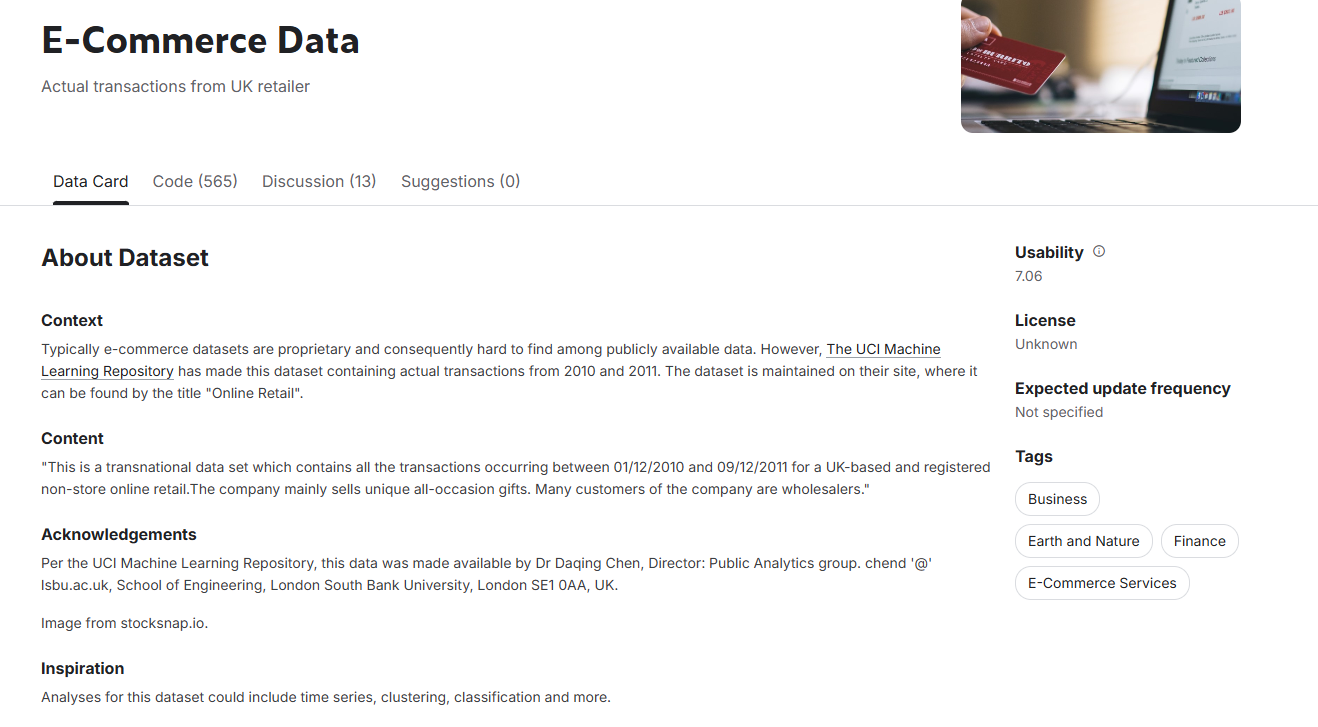

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,7)) # to make sure all charts are automatically generated at (20,7), because i am blind

<Figure size 2000x700 with 0 Axes>

<Figure size 2000x700 with 0 Axes>

In [51]:
encodings = ["utf-8", "latin1", "cp1252", "ISO-8859-1"]

for enc in encodings:
    try:
        df = pd.read_csv("data.csv", encoding=enc)
        print(f"Success with encoding: {enc}")
        break
    except UnicodeDecodeError:
        print(f"Failed with encoding: {enc}")

df.head()

Failed with encoding: utf-8
Success with encoding: latin1


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [53]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [54]:
df.duplicated().sum()

5268

In [55]:
# what % of the data rows are duplicated?
duplicate_count = df.duplicated().sum()
duplicate_percent = round((duplicate_count / df.shape[0]) * 100, 2)

print("Duplicated rows:", duplicate_count)
print("Duplicated %:", duplicate_percent)

Duplicated rows: 5268
Duplicated %: 0.97


In [56]:
# View all duplicate rows together
duplicate_rows = df[df.duplicated(keep=False)]

# Sort duplicate rows so matching records appear beside each other
duplicate_rows_sorted = duplicate_rows.sort_values(
    by=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
)

duplicate_rows_sorted.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [57]:
duplicate_rows_sorted.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID     85
Country         0
dtype: int64

In [58]:
# Display the original shape of the dataframe
print("Original shape:", df.shape)

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Display the new shape
print("Cleaned shape:", df.shape)

# Confirm duplicates removed
print("Remaining duplicated rows:", df.duplicated().sum())

Original shape: (541909, 8)
Cleaned shape: (536641, 8)
Remaining duplicated rows: 0


># InvoiceNo

In [59]:
print("Total rows:", df.shape[0])
print("Unique InvoiceNo:", df['InvoiceNo'].nunique())
print("Repeated InvoiceNo rows:", df.shape[0] - df['InvoiceNo'].nunique())

Total rows: 536641
Unique InvoiceNo: 25900
Repeated InvoiceNo rows: 510741


<li>InvoiceNo has no missing values. However, it is not unique because each invoice can contain multiple product line items. 
<li>The dataset has 541,909 rows but only 25,900 unique invoice numbers, meaning many invoice numbers appear repeatedly. 
<li>This is expected in retail transaction data and does not automatically mean the rows are duplicates- besides, we removed the duplicates

># Description

In [60]:
df['Description'].isnull().sum()

1454

In [61]:
# Lets veiw the slice of df where Description are NULL
df_description_null = df[df['Description'].isnull()]

df_description_null.head(100)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
21785,538136,37509,NaN,2,12/9/2010 15:57,0.0,NaN,United Kingdom
21786,538137,62095B,NaN,2,12/9/2010 15:57,0.0,NaN,United Kingdom
21787,538138,72814,NaN,2,12/9/2010 15:57,0.0,NaN,United Kingdom
21788,538139,84802A,NaN,2,12/9/2010 15:57,0.0,NaN,United Kingdom


In [62]:
#This prints the total number of rows where the Description column is missing. 
# Since df_description_null was created by filtering rows with null descriptions, .shape[0] gives the row count.
print("Rows with missing Description:", df_description_null.shape[0])

#This checks how many of the missing-description rows also have UnitPrice equal to 0. The filter:
print("Missing Description + UnitPrice = 0:",
      df_description_null[df_description_null['UnitPrice'] == 0].shape[0])

#
print("Missing Description + CustomerID is null:",
      df_description_null[df_description_null['CustomerID'].isnull()].shape[0])

print("Missing Description + UnitPrice = 0 + CustomerID is null:",
      df_description_null[
          (df_description_null['UnitPrice'] == 0) &
          (df_description_null['CustomerID'].isnull())
      ].shape[0])

Rows with missing Description: 1454
Missing Description + UnitPrice = 0: 1454
Missing Description + CustomerID is null: 1454
Missing Description + UnitPrice = 0 + CustomerID is null: 1454


<li>The above code investigates whether missing product descriptions are random or connected to other issues. 
<li>We found that all rows with missing Description also have UnitPrice = 0 and missing CustomerID. 
<li>This suggests these records may not represent normal sales transactions because they have no product description, no customer ID, and no price.

In [63]:
# Ohhh we see a negative value in Quantity
df_description_null[df_description_null['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
517719,580087,84341B,NaN,-2,12/1/2011 14:27,0.0,NaN,United Kingdom
521333,580359,20775,NaN,-35,12/2/2011 16:11,0.0,NaN,United Kingdom
522160,580379,72225C,NaN,-144,12/2/2011 17:57,0.0,NaN,United Kingdom
522162,580381,21758,NaN,-9,12/2/2011 17:58,0.0,NaN,United Kingdom


<li>It seems we have 862 rows within the df_description_null dataframe where we have negative Quantity values and UnitPrice is also 0. WHAT does this mean???
<li>I do not understand this accounting concept at all.

In [64]:
# Create a new column to Flag rows where Description was originally missing
df['Missing_Description_Flag'] = df['Description'].isnull()

# Fill missing Description values with a meaningful label like 'Zero-Value Stock Adjustment'
df['Description'] = df['Description'].fillna('Zero-Value Stock Adjustment') ## since this also appies to negative Quantity values

# Confirm missing descriptions are filled
df['Description'].isnull().sum()

0

In [65]:
df['Missing_Description_Flag'].value_counts()

Missing_Description_Flag
False    535187
True       1454
Name: count, dtype: int64

In [66]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Missing_Description_Flag'],
      dtype='object')

># InvoiceDate

This column will be converted to datetime when we begin analyzing the cleaned data set. No need to change right now.

># Quantity

In [67]:
df['Quantity'].dtype

dtype('int64')

In [68]:
# Split Quantity into negative, zero and positive dataframes
df_quantity_negative = df[df ['Quantity'] < 0]
df_quantity_zero = df[df ['Quantity'] == 0]
df_quantity_positive = df[df ['Quantity'] > 0]

print("Negative Quantity rows:", df_quantity_negative.shape[0])
print("Zero Quantity rows:", df_quantity_zero.shape[0])
print("Positive Quantity rows:", df_quantity_positive.shape[0])

Negative Quantity rows: 10587
Zero Quantity rows: 0
Positive Quantity rows: 526054


In [69]:
# lets inspect the dataframe where we have negative values for Quantity
df_quantity_negative.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,False
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,False
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,False
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom,False
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,False
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom,False
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom,False


In [70]:
#It seems as though InvoiceNo start with a C in this Quanity Nagative dataframe.
# Are all InvoiceNo here start with "C"
df_quantity_negative['InvoiceNo'].astype(str).str.startswith('C').value_counts()


InvoiceNo
True     9251
False    1336
Name: count, dtype: int64

<li>We checked whether negative quantities were associated with invoice numbers starting with C. 
<li>Since 9,288 negative quantity rows had invoice numbers beginning with C, these records likely represent cancelled orders or returns. 
<li>The remaining 1,336 negative quantity rows did not begin with C, so they may represent stock adjustments, corrections, or other non-standard records.

In [71]:
# Lets look at the slice/dataframe where InvoiceNO do NOT start with "C"
df_quantity_negative_not_c = df_quantity_negative[
    ~df_quantity_negative['InvoiceNo'].astype(str).str.startswith('C')
]

df_quantity_negative_not_c.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag
2406,536589,21777,Zero-Value Stock Adjustment,-10,12/1/2010 16:50,0.0,NaN,United Kingdom,True
4347,536764,84952C,Zero-Value Stock Adjustment,-38,12/2/2010 14:42,0.0,NaN,United Kingdom,True
7188,536996,22712,Zero-Value Stock Adjustment,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,True
7189,536997,22028,Zero-Value Stock Adjustment,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,True
7190,536998,85067,Zero-Value Stock Adjustment,-6,12/3/2010 15:30,0.0,NaN,United Kingdom,True
7192,537000,21414,Zero-Value Stock Adjustment,-22,12/3/2010 15:32,0.0,NaN,United Kingdom,True
7193,537001,21653,Zero-Value Stock Adjustment,-6,12/3/2010 15:33,0.0,NaN,United Kingdom,True
7195,537003,85126,Zero-Value Stock Adjustment,-2,12/3/2010 15:33,0.0,NaN,United Kingdom,True
7196,537004,21814,Zero-Value Stock Adjustment,-30,12/3/2010 15:34,0.0,NaN,United Kingdom,True
7197,537005,21692,Zero-Value Stock Adjustment,-70,12/3/2010 15:35,0.0,NaN,United Kingdom,True


In [72]:
# we see UnitPrice=0: are all rows within UnitPrice =0?
df_quantity_negative_not_c['UnitPrice'].describe()

count    1336.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: UnitPrice, dtype: float64

In [73]:
df_quantity_negative_not_c['CustomerID'].value_counts()

Series([], Name: count, dtype: int64)

<li>Negative Quantity rows that do not start with "C" were investigated separately.
<li>All 1,336 of these records have missing CustomerID and UnitPrice = 0.
<li>Since they are not linked to a customer and do not generate revenue, they are likely internal zero-value stock adjustments rather than cancelled customer orders.

What about the slice/datafra,e where InvoiceNo startes with C?

In [74]:
df_quantity_negative_c = df_quantity_negative[
    df_quantity_negative['InvoiceNo'].astype(str).str.startswith('C')
]

df_quantity_negative_c.shape

(9251, 9)

In [75]:
df_quantity_negative_c.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,False
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,False


In [76]:
# Check cancelled invoice and possible original invoice
df[df['InvoiceNo'].isin(['C536383', '536383'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,False


C536383 is a cancellation/return transaction, but the original sale invoice is not necessarily stored as 536383.

In [77]:
# where there any null values in Descriotion column before we reoplaced the null values within this dataframe? Check using hte column "Missing_Description_Flag"
df_quantity_negative_c['Missing_Description_Flag'].value_counts()

Missing_Description_Flag
False    9251
Name: count, dtype: int64

In [78]:
df_quantity_negative_c[['UnitPrice', 'Quantity']].describe()

,UnitPrice,Quantity
count,9251.000000,9251.000000
mean,48.570430,-29.787050
std,667.926393,1147.997592
min,0.010000,-80995.000000
25%,1.450000,-6.000000
50%,2.950000,-2.000000
75%,5.950000,-1.000000
max,38970.000000,-1.000000


<li>Negative Quantity rows where InvoiceNo starts with "C" appear to be cancelled orders or returns.
<li>These records have valid descriptions and positive UnitPrice values.
<li>Unlike zero-value stock adjustments, these records affect revenue because Quantity * UnitPrice produces negative revenue.

In [79]:
#create a new column to flag the cancelled orderes
df['Cancelled_Order_Flag'] = (
    (df['Quantity'] < 0) &
    (df['InvoiceNo'].astype(str).str.startswith('C'))
)

df['Cancelled_Order_Flag'].value_counts()

"""# Created a flag to identify likely cancelled orders.
# These rows have negative Quantity and InvoiceNo starts with "C".
# They are different from zero-value stock adjustments because they have valid product descriptions
# and positive UnitPrice values, meaning they affect revenue as negative sales/returns."""

'# Created a flag to identify likely cancelled orders.\n# These rows have negative Quantity and InvoiceNo starts with "C".\n# They are different from zero-value stock adjustments because they have valid product descriptions\n# and positive UnitPrice values, meaning they affect revenue as negative sales/returns.'

In [80]:
df['Cancelled_Order_Flag'].value_counts()

Cancelled_Order_Flag
False    527390
True       9251
Name: count, dtype: int64

In [81]:
df_quantity_negative_c.shape[0]

9251

In [82]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Missing_Description_Flag',
       'Cancelled_Order_Flag'],
      dtype='object')

># UnitPrice

In [83]:
df['UnitPrice'].describe()

count    536641.000000
mean          4.632656
std          97.233118
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [84]:
# Create separate dataframes based on UnitPrice values
df_unitprice_negative = df[df['UnitPrice'] < 0]
df_unitprice_zero = df[df['UnitPrice'] == 0]
df_unitprice_positive = df[df['UnitPrice'] > 0]

print("Negative UnitPrice rows:", df_unitprice_negative.shape[0])
print("Zero UnitPrice rows:", df_unitprice_zero.shape[0])
print("Positive UnitPrice rows:", df_unitprice_positive.shape[0])

Negative UnitPrice rows: 2
Zero UnitPrice rows: 2510
Positive UnitPrice rows: 534129


In [85]:
# investigate the 2 rows within the df_unitprice_negative where UnitPrice is negative.
df_unitprice_negative

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag,Cancelled_Order_Flag
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom,False,False
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom,False,False


In [86]:
df[(df['UnitPrice'] == 11062.06)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag,Cancelled_Order_Flag
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,False,False


In [87]:
df[(df['UnitPrice'] == -11062.06)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag,Cancelled_Order_Flag
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom,False,False
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom,False,False


In [88]:
# Remove the extra bad debt adjustment row
df=df.drop(index=299984)

# Confirm the row was removed
299984 in df.index

False

In [89]:
df['UnitPrice'].describe()

count    536640.000000
mean          4.653278
std          96.052467
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [90]:
# Keep only rows where UnitPrice is not zero
df_new = df[df['UnitPrice'] != 0].copy()

# Check shape before and after
print("df shape:", df.shape)
print("df_new shape:", df_new.shape)

# Confirm zero UnitPrice rows are removed
print("Zero UnitPrice rows in df_new:", (df_new['UnitPrice'] == 0).sum())

df shape: (536640, 10)
df_new shape: (534130, 10)
Zero UnitPrice rows in df_new: 0


<li>Moving forward, Rows with `UnitPrice = 0` were removed because they do not represent normal sales transactions. 
<li>These records may represent accounting adjustments, stock movements, or non-sales activity. 
<li>The cleaned dataset moving forward is saved as `df_new`.

># CustomerID

In [91]:
df_new['CustomerID'].isnull().sum()

132566

In [92]:
# Create dataframe where CustomerID is missing
df_missing_customer = df_new[df_new['CustomerID'].isnull()].copy()

# Check shape
print("Rows with missing CustomerID:", df_missing_customer.shape[0])

# View first few rows
df_missing_customer.head()

Rows with missing CustomerID: 132566


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Missing_Description_Flag,Cancelled_Order_Flag
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom,False,False
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom,False,False
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom,False,False
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom,False,False
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom,False,False


In [93]:
display(df_missing_customer['Cancelled_Order_Flag'].value_counts())
display(df_missing_customer['Missing_Description_Flag'].value_counts())


Cancelled_Order_Flag
False    132187
True        379
Name: count, dtype: int64

Missing_Description_Flag
False    132566
Name: count, dtype: int64

In [94]:
# Create readable CustomerID label
df_new['CustomerID_Label'] = df_new['CustomerID'].apply(
    lambda x: 'Unknown Customer' if pd.isna(x) else str(int(x))
)

# Confirm result
df_new[['CustomerID', 'CustomerID_Label']].head(10)

,CustomerID,CustomerID_Label
0,17850.0,17850
1,17850.0,17850
2,17850.0,17850
3,17850.0,17850
4,17850.0,17850
5,17850.0,17850
6,17850.0,17850
7,17850.0,17850
8,17850.0,17850
9,13047.0,13047


In [95]:
# Count known vs unknown customers
df_new['CustomerID_Label'].eq('Unknown Customer').value_counts()

CustomerID_Label
False    401564
True     132566
Name: count, dtype: int64

<li>So the missing customer rows are not mostly garbage rows anymore. They all have descriptions, and most of them are not cancelled orders.
<li>That means we should not delete all missing CustomerID rows. If we delete them, we lose a lot of valid product/country/date/sales information.
<li>CustomerID has missing values, but these rows were kept because they still contain valid transaction details such as InvoiceNo, Description, Quantity, InvoiceDate, UnitPrice, and Country. 
<li>Missing CustomerID values were labelled as "Unknown Customer" for customer-level analysis.

In [96]:
df_new.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Missing_Description_Flag',
       'Cancelled_Order_Flag', 'CustomerID_Label'],
      dtype='object')

In [97]:
df_new.isnull().sum()

InvoiceNo                        0
StockCode                        0
Description                      0
Quantity                         0
InvoiceDate                      0
UnitPrice                        0
CustomerID                  132566
Country                          0
Missing_Description_Flag         0
Cancelled_Order_Flag             0
CustomerID_Label                 0
dtype: int64

### CustomerID Missing Values

After removing duplicates and zero UnitPrice records, the only remaining missing values are in the `CustomerID` column.

These rows were kept because they still contain valid invoice, product, quantity, date, price, and country information. Removing them would reduce the dataset significantly and could distort sales, product, country, and time-based analysis.

A new column, `CustomerID_Label`, was created to label missing customer IDs as `Unknown Customer`.

># Saved Cleaned File

In [98]:
# Save cleaned dataframe to CSV
df_new.to_csv("Online_Retail_clean2.csv", index=False)

print("File saved successfully as Online_Retail_clean2.csv")

File saved successfully as Online_Retail_clean2.csv
